In [13]:
from datasets import load_dataset
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Load the Oxford Flowers 102 dataset
dataset = load_dataset("dpdl-benchmark/oxford_flowers102")

# Filter out classes with < 50 total images across all splits

# Count labels across ALL splits
all_labels = (
    [item["label"] for item in dataset["train"]] +
    [item["label"] for item in dataset["validation"]] +
    [item["label"] for item in dataset["test"]]
)

# Count occurrences of each label
label_counts = Counter(all_labels)

# Keep classes with >= 50 total images
valid_classes = sorted([label for label, count in label_counts.items() if count >= 50])

print(f"Keeping {len(valid_classes)} classes out of 102")

# Create label mapping (old → new)
label_map = {old: new for new, old in enumerate(valid_classes)}

# Filter function
def filter_dataset(hf_split):
    return hf_split.filter(lambda x: x["label"] in valid_classes)

# Remap function
def remap_labels(example):
    example["label"] = label_map[example["label"]]
    return example

# Apply filtering to remove unwanted classes
dataset["train"] = filter_dataset(dataset["train"]).map(remap_labels)
dataset["validation"] = filter_dataset(dataset["validation"]).map(remap_labels)
dataset["test"] = filter_dataset(dataset["test"]).map(remap_labels)

# Print new class distribution
print("Train size:", len(dataset["train"]))
print("Val size:", len(dataset["validation"]))
print("Test size:", len(dataset["test"]))

# Image size for ResNet
IMG_SIZE = 224

# Transforms for training and testing
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset class to wrap Hugging Face splits
class HFFlowersDataset(Dataset):
    def __init__(self, hf_split, transform=None):
        self.data = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"]
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# Create PyTorch Datasets and DataLoaders
train_ds = HFFlowersDataset(dataset["train"], train_transform)
val_ds = HFFlowersDataset(dataset["validation"], test_transform)
test_ds = HFFlowersDataset(dataset["test"], test_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained ResNet50 and modify final layer
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Unfreeze layer3, layer4, fc
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# Replace final layer
num_classes = len(valid_classes)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3), 
    nn.Linear(512, num_classes)
)

model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 3e-5},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

# Training function
def train(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Evaluation function
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = correct / len(loader.dataset)

    return avg_loss, accuracy

# Prediction function for test set
def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)

            preds = outputs.argmax(dim=1).cpu().numpy()
            labels = labels.cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    return all_labels, all_preds

# Training loop with early stopping

# Save training history for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

epochs = 20
best_val = 0
patience = 5
counter = 0

for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    val_loss, val_acc = evaluate(model, val_loader)

    # Store values for plotting
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val:
        best_val = val_acc
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

# Print final test accuracy
test_loss, test_acc = evaluate(model, test_loader)

# Get predictions
y_true, y_pred = get_predictions(model, test_loader)

# Basic metrics
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("\n===== FINAL METRICS =====")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Keeping 74 classes out of 102
Train size: 740
Val size: 740
Test size: 5483
Epoch 1
Train Loss: 4.2340, Train Acc: 0.0622
Val Loss: 3.9298, Val Acc: 0.3351
Epoch 2
Train Loss: 3.4528, Train Acc: 0.3486
Val Loss: 2.8136, Val Acc: 0.4905
Epoch 3
Train Loss: 2.2404, Train Acc: 0.5162
Val Loss: 1.8300, Val Acc: 0.5811
Epoch 4
Train Loss: 1.4153, Train Acc: 0.6595
Val Loss: 1.3669, Val Acc: 0.6811
Epoch 5
Train Loss: 1.0839, Train Acc: 0.7716
Val Loss: 1.1288, Val Acc: 0.7149
Epoch 6
Train Loss: 0.8424, Train Acc: 0.8054
Val Loss: 0.9434, Val Acc: 0.7676
Epoch 7
Train Loss: 0.6885, Train Acc: 0.8230
Val Loss: 0.9535, Val Acc: 0.7568
Epoch 8
Train Loss: 0.5728, Train Acc: 0.8500
Val Loss: 0.8713, Val Acc: 0.7757
Epoch 9
Train Loss: 0.5106, Train Acc: 0.8595
Val Loss: 0.7739, Val Acc: 0.7784
Epoch 10
Train Loss: 0.5046, Train Acc: 0.8905
Val Loss: 0.7319, Val Acc: 0.8068
Epoch 11
Train Loss: 0.4674, Train Acc: 0.8932
Val Loss: 0.7283, Val Acc: 0.8189
Epoch 12
Train Loss: 0.4625, Train Acc: 0.

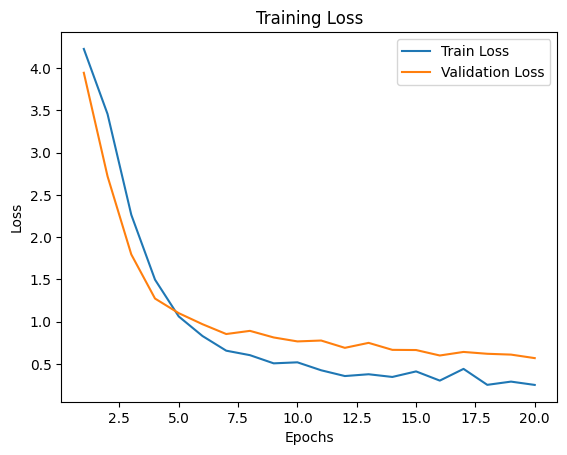

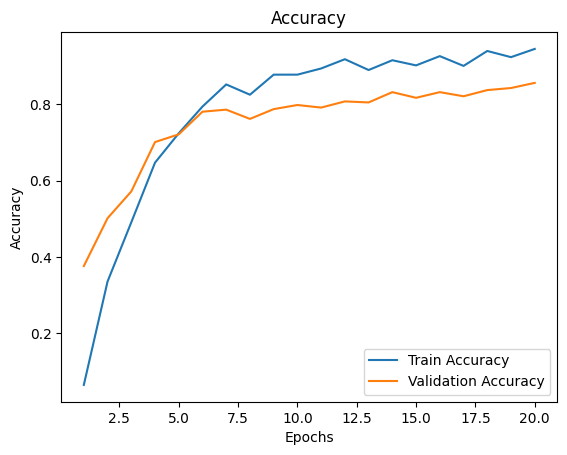

In [11]:
# Plotting training history
epochs_range = range(1, len(train_losses) + 1)

# Loss graph
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

# Accuracy graph
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

In [6]:
# Save the model
torch.save(model.state_dict(), "flower_classifier.pth")

In [7]:
class_names = [dataset["train"].features["label"].names[i] for i in valid_classes]

import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)